# Практическая работа №3
# "Дискриминантный анализ LDA/QDA & Тематическое моделирование LSA/pLSA"



> @Гришина Ксения, 23.Б16-мм



## 📒 Полный текст задания
(из файла с дз, дублирую для удобства)

> Практическая работа № 3

> Ваша задача будет попробовать использовать LDA/QDA и тематическое моделирование (Probabilistic LSA) на данных, которые Вы выбрали.
> 1. Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов.
2. Обработать данные (взять 1 лабораторную работу), но здесь уже добавляется проверка на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной (см. Практическую работу 5). Ваша задача сделать анализ и обработать данные так, чтобы получить максимальную точность.
3. Использовать LDA/QDA (ссылка на презентацию лекции: https://drive.google.com/file/d/1BKB0q27xTX3aBLTsfd9szKrzluUvyJdL/view?usp=drive_link) .
4. Использовать Probabilistic LSA (ссылка на презентацию лекции: https://drive.google.com/file/d/1wv7rXv4feY7ePpsA0wPOtuZuPV3DrACB/view?usp=drive_link) .
5. Основные метрики качества проверки: **Accuracy** для LDA/QDA; **Perplexity** для LSA (сколько информации сохраняет k-мерное пространство)
6. Сделать понятные, четкие выводы по каждому алгоритму на датасет выбранном для 3 работы.
7. Сделать выводы по тому,  какой из методов более уместно использовать для Вашего выбранного датасета (тот, который Вы применяли на 1 и 2 практической)


> Если вдруг Ваши данные не подходят под алгоритмы, то можете использовать другие, но это относится только к этой работе (№ 3) и новый датасет также нужно будет описать (признаки + ссылку на источник).

> Работа должна представлять собой ноутбук в GoogleCollab или Kagle (ссылка), оставленный комментарием напротив Вашей фамилии и даты выдачи работ. Также, ноутбук должен быть только с доступом просмотра к моей почте (!!!). Почта: o.gavrilenko.r@gmail.com

 >Замечание: если будет использован GPT (как копипаст), то работа не будет засчитана. Если Вы предоставляете работу с использованием GPT - кода и это вычисляется, но это не полностью копипаст, то будет снижено 50% баллов. GPT можно использовать как источник информации, но это не должно быть скопировано и неосмысленно отправлено на проверку.
> P.S.: Проверяйте открытые доступы к моему аккаунту, иначе работа не будет засчитана, как сданная.

> P.P.S: GPT можно использовать для построения графиков, но интерпретация графиков должна быть написана Вашими словами

> ДД данной работы: 13.10.2025 до 23:59

## ∀ Импорты

In [ ]:
import os
from google.colab import drive

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD


## 1 Теоретическая справка
<!--
Теоретическая справка: цель работы, задачи работы, используемые алгоритмы – необходимо небольшое описание алгоритмов. -->

**Цель работы** - Использовать LDA(Linear Discriminant Analysis) / QDA(Quadratic Discriminant Analysis), Probabilistic LSA – тематическое моделирование на данных.

**Задачи работы**:

1) Подготовить данные к задаче классификации и применения LDA/QDA. Применить методы. Посчитать метрики качества. Сделать выводы.
2) Подготовить или найти более подходящие данные и обработать их для применения тематического моделирования pLSA. Применить метод. Посчитать метрики качества. Сделать выводы.

**Используемые алгоритмы:**
- LDA/QDA
- pLSA




> Небольшое большое описание алгоритмов:

**1.a) LDA**

> Цель: Разделить классы с помощью линейной границы.

> Идея: Признаки каждого класса распределены нормально с одинаковой ковариационной матрицей `Σ`.  
Алгоритм строит линейное сочетание признаков, которое максимизирует различие между классами и минимизирует разброс внутри классов.

> Дискриминантная классифицирующая функция для класса i:  

> $$
h_i(x) = - \frac{1}{2} \mu_i^\top \Sigma^{-1} \mu_i + \mu_i^\top \Sigma^{-1} x  + \log \pi_i
$$

> где:  
> - $x$ — вектор признаков  
> - $\mu_k$ — вектор средних признаков класса $k$  
> - $\Sigma$ — общая ковариационная матрица  
> - $\pi_k$ — априорная вероятность класса $k$  

> Особенности:  
> - Линейная граница между классами  
> - Эффективна при схожей ковариации классов и небольшом объёме данных  


 **1.b) QDA (Quadratic Discriminant Analysis)**

> Цель: Разделить классы с помощью квадратичной границы, учитывая различия в ковариациях классов.

> Идея: Признаки каждого класса распределены нормально, но с разными ковариационными матрицами $\Sigma_k$.  
Позволяет учитывать более сложные зависимости между признаками.

> Дискриминантная классифицирующая функция для класса i:  

> $$
g_i(x) = \log \pi_i -\frac{1}{2} \log |\Sigma_i| - \frac{1}{2} (x - \mu_i)^\top \Sigma_i^{-1} (x - \mu_i)
$$

> Особенности:  
> - Квадратичные границы между классами  
> - Гибче, чем LDA, но требует больше данных для точной оценки ковариаций


**2. a) LSA (Latent Semantic Analysis)**

> Цель:
Выявление скрытых семантических связей между словами и документами.
Каждый документ и каждое слово представляются в общем латентном пространстве смыслов.

> Модель:
Пусть $X$ — матрица <<документ–терм>>, где элемент $x_{dw}$ — частота слова $w$ в документе $d$.
Метод LSA выполняет сингулярное разложение:
$
X \approx U_k \Sigma_k V_k^{\top}
$
где:
> - $U_k$ — матрица документов в пространстве $k$ скрытых факторов,
> - $V_k$ — матрица слов в том же пространстве,
> - $\Sigma_k$ — диагональная матрица сингулярных значений (важность факторов).


> Обучение:
SVD (Singular Value Decomposition) — выделяет главные направления в данных, устраняя шум и корреляции между словами.

> Особенности:

> - Основан на линейной алгебре (не вероятностная модель);
> - Требует выбора размерности $k$;
> - Является детерминированным аналогом pLSA.




**2. b) pLSA (Probabilistic Latent Semantic Analysis)**

> Цель: Выявление скрытых тем в корпусе документов. Каждый документ — смесь тем, каждая тема — распределение слов.

> Модель:  
$$
P(w \mid d) = \sum_{z \in Z} P(w \mid z) P(z \mid d)
$$
где:  
> - $P(w \mid z)$ — вероятность слова $w$ в теме $z$  
> - $P(z \mid d)$ — вероятность темы $z$ в документе $d$

> Обучение:  
Метод EM (Expectation-Maximization) для оценки $P(w \mid z)$ и $P(z \mid d)$, максимизируя лог-правдоподобие:

> $$
L = \sum_{d \in D} \sum_{w \in W} n(d,w) \log \left( \sum_{z \in Z} P(w \mid z) P(z \mid d) \right)
$$

> Особенности:  
> - Вероятностная альтернатива LSA (в LSA предполагается, что из нормального, тут -- из мультиномиального распределения)
> - Позволяет выявлять скрытые темы  
> - Требует специфической предобработки

## 2 Обработка данных

 <!-- Обработать данные (взять 1 лабораторную работу), но здесь уже добавляется проверка на дисбаланс классов, на корреляцию признаков и корреляцию с целевой переменной (см. Практическую работу 5). Ваша задача сделать анализ и обработать данные так, чтобы получить максимальную точность. -->

### a) Частичный повтор практической работы №1

#### 1 Теоретическая справка

Для поиска своего набора данных воспользовалась поиском в [kaggle](https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat). Выбрала такой датасет о продажах видеоигр
(https://www.kaggle.com/datasets/ibriiee/video-games-sales-dataset-2022-updated-extra-feat)

На kaggle дали такое описание данным:



> Этот набор данных предоставляет актуальную информацию о продажах и популярности различных видеоигр по всему миру. Данные включают название, платформу, год выпуска, жанр, издателя и данные о продажах в Северной Америке, Европе, Японии и других регионах. Он также содержит оценки и рейтинги критиков и пользователей, включая средний рейтинг критиков, количество просмотренных игр, средний рейтинг пользователей, количество просмотренных игр, разработчика и рейтинг. Этот всеобъемлющий и важный набор данных предоставляет ценную информацию о мировом рынке видеоигр и является незаменимым инструментом для геймеров, профессионалов отрасли и исследователей рынка.



Записей: 16719.

**Признаки**(16 шт):
| Название колонки | Описание |
|------------------|----------|
| Name             | Название видеоигры |
| Platform         | Платформа, на которой была выпущена игра (PlayStation, Xbox, Nintendo и др.) |
| Year of Release  | Год выпуска игры |
| Genre            | Жанр видеоигры (экшен, приключения, спорт и др.) |
| Publisher        | Компания, выпустившая игру |
| NA Sales         | Продажи игры в Северной Америке (в млн USD) |
| EU Sales         | Продажи игры в Европе (в млн USD) |
| JP Sales         | Продажи игры в Японии (в млн USD) |
| Other Sales      | Продажи игры в других регионах (в млн USD) |
| Global Sales     | Общие мировые продажи игры (в млн USD) |
| Critic Score     | Средняя оценка игры от профессиональных критиков (0-100)|
| Critic Count     | Количество критиков, оценивших игру |
| User Score       | Средняя оценка игры от пользователей (0-10)|
| User Count       | Количество пользователей, оценивших игру |
| Developer        | Компания, разработавшая игру |
| Rating           | Возрастной рейтинг игры (ESRB, PEGI и др.) |


На этих данных можно выполнять **задачи**:
- первичный анализ данных (есть пропуски и некорректные типы данных)
- регрессии (наиболее естественная, предсказать Global_Sales)
- классификации (например, по жанру, рейтингу или платформе)
- кластеризации (группировать схожие игры)

**Задача на эту работу** - первичный анализ данных.
по содержанию ноутбука будет видно, какие шаги для этого потребовалось выполнить.

#### 2 Датасет

- Датасет индивидуален, был привязан ко мне комментарием в табличке курса

Считаем скачанный датасет

In [ ]:
# 1. Добавлять напрямую, так делала в работе №1
# data = pd.read_csv('Video_Games.csv')

# 2. через mount. Это удобнее, так делаю в работе №2 и далее
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/Video_Games.csv')

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [ ]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


Все успешно подгрузилось.
- Заметим, что в данных **есть пропуски, как количественые, так и категориальные признаки**

Также, сразу узнаем основную информацию о датафрейме "по факту"

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `'Year_of_Release'` типа `float`)

**Вывод**: датасет согласуется с требованиями (не самый чистый).

#### 3 Обработка пропусков

из инфо выше видно, что у двух записей не хватает названия игры. можно предположить, что данные там некорректно собирались, и по логике их можно удалить.

In [ ]:
# Удаляем строки, где Name пустое
data = data.dropna(subset=['Name'])

Заполним медианой год выпуска

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Year_of_Release'] = data['Year_of_Release'].fillna(data['Year_of_Release'].median())

Заполним модой издателя

In [ ]:
# Категориальные признаки заполним модой
data['Publisher'] = data['Publisher'].fillna(data['Publisher'].mode()[0])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


для признаков, связанных с оценками очень много пропусков (~8к). удалив их мы потеряем половину датасета, а заполнив медианой придется учитывать, что мы могли исказить исходное распределение.



In [ ]:
data['Critic_Score'].unique()

array([76., nan, 82., 80., 89., 58., 87., 91., 61., 97., 95., 77., 88.,
       83., 94., 93., 85., 86., 98., 96., 90., 84., 73., 74., 78., 92.,
       71., 72., 68., 62., 49., 67., 81., 66., 56., 79., 70., 59., 64.,
       75., 60., 63., 69., 50., 25., 42., 44., 55., 48., 57., 29., 47.,
       65., 54., 20., 53., 37., 38., 33., 52., 30., 32., 43., 45., 51.,
       40., 46., 39., 34., 35., 41., 36., 28., 31., 27., 26., 19., 23.,
       24., 21., 17., 22., 13.])

In [ ]:
# Числовые признаки заполним медианой (устойчива к выбросам)
data['Critic_Score'] = data['Critic_Score'].fillna(data['Critic_Score'].median())
data['Critic_Count'] = data['Critic_Count'].fillna(data['Critic_Count'].median())

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.2+ MB


In [ ]:
# при попытке заполнить пропуски вышла ошибка, посмотрим какие значения принимает этот признак
data['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [ ]:
tbd_count = (data['User_Score'] == 'tbd').sum()
print(f"Количество 'tbd': {tbd_count}")

Количество 'tbd': 2425


In [ ]:
# Преобразуем в числа, нечисловые значения станут NaN
data['User_Score'] = pd.to_numeric(data['User_Score'], errors='coerce')
# Заполним их медианой
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())

# Проверка
data['User_Score'].unique()

array([8. , 7.5, 8.3, 8.5, 6.6, 8.4, 8.6, 7.7, 6.3, 7.4, 8.2, 9. , 7.9,
       8.1, 8.7, 7.1, 3.4, 5.3, 4.8, 3.2, 8.9, 6.4, 7.8, 2.6, 7.2, 9.2,
       7. , 7.3, 4.3, 7.6, 5.7, 5. , 9.1, 6.5, 8.8, 6.9, 9.4, 6.8, 6.1,
       6.7, 5.4, 4. , 4.9, 4.5, 9.3, 6.2, 4.2, 6. , 3.7, 4.1, 5.8, 5.6,
       5.5, 4.4, 4.6, 5.9, 3.9, 3.1, 2.9, 5.2, 3.3, 4.7, 5.1, 3.5, 2.5,
       1.9, 3. , 2.7, 2.2, 2. , 9.5, 2.1, 3.6, 2.8, 1.8, 3.8, 0. , 1.6,
       9.6, 2.4, 1.7, 1.1, 0.3, 1.5, 0.7, 1.2, 2.3, 0.5, 1.3, 0.2, 0.6,
       1.4, 0.9, 1. , 9.7])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


In [ ]:
data['User_Score'] = data['User_Score'].fillna(data['User_Score'].median())
data['User_Count'] = data['User_Count'].fillna(data['User_Count'].median())

Так как пропуски в этих признаках есть в почти половине записей, заполнять стат методами мы можем изменить распределение. Создадим новую категорию, чтобы не искажать исходные данные.

In [ ]:
# заполняем пропуски в рейтинге значением "неизвестно"
data["Rating"] = data["Rating"].fillna("Unknown")
data["Developer"] = data["Developer"].fillna("Unknown")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16717 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16717 non-null  object 
 2   Year_of_Release  16717 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16717 non-null  object 
 5   NA_Sales         16717 non-null  float64
 6   EU_Sales         16717 non-null  float64
 7   JP_Sales         16717 non-null  float64
 8   Other_Sales      16717 non-null  float64
 9   Global_Sales     16717 non-null  float64
 10  Critic_Score     16717 non-null  float64
 11  Critic_Count     16717 non-null  float64
 12  User_Score       16717 non-null  float64
 13  User_Count       16717 non-null  float64
 14  Developer        16717 non-null  object 
 15  Rating           16717 non-null  object 
dtypes: float64(10), object(6)
memory usage: 2.2+ MB


**Вывод**: заполнили пропуски, стараясь сохранить реальность данных и применимость к основным задачам датасета

#### 4 Обработка выбросов

Для начала, было бы неплохо узнать, есть ли они вообще. Для этого посмотрим на Q3 и max в инфо или на боксплотах.

In [ ]:
data.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.000000,16717.00000,16717.000000
mean,2006.497218,0.263255,0.145010,0.077610,0.047333,0.533462,70.010767,23.609380,7.32976,86.760364
std,5.830342,0.813475,0.503303,0.308836,0.186721,1.547956,9.776915,13.510184,1.02779,384.399216
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.00000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,71.000000,21.000000,7.50000,24.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,7.50000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,71.000000,21.000000,7.50000,24.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,9.70000,10665.000000


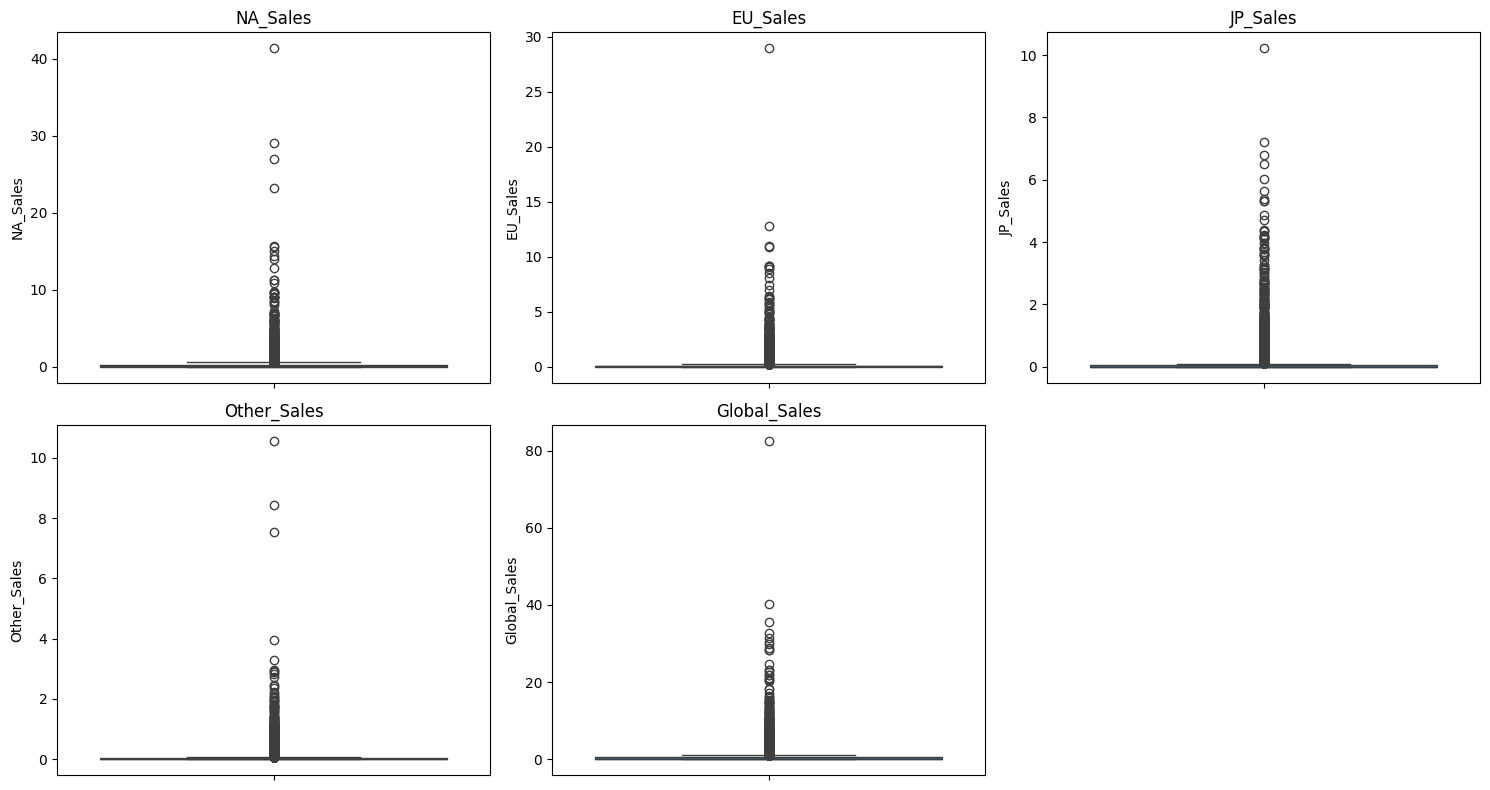

In [ ]:
# Список столбцов продаж
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

plt.figure(figsize=(15, 8))

# Проходим по каждому столбцу и строим боксплот
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)  # создаём сетку 2x3
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Выяснили, что наши данные очень асимметричны, т е что есть и очень успешные игры, с продажами сильно выше среднего, и провальные проекты. Но в основном у нас не совсем так, поэтому на них можно смотреть как на выбросы. (Зависит от задачи.)

Прологарифмировав данные мы можем избавиться от тяжелых хвостов и сделать их более симметричными.

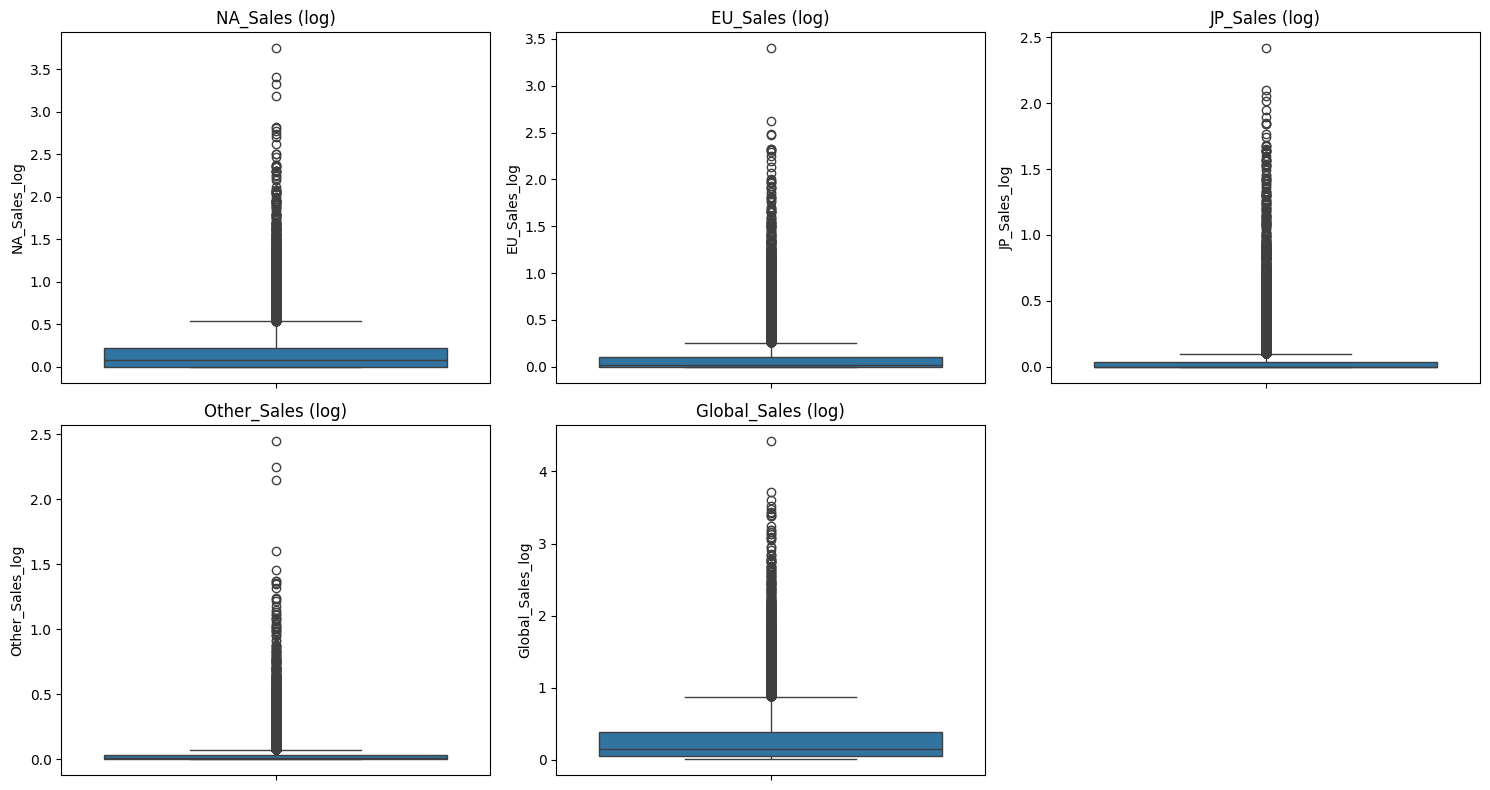

In [ ]:
# создаём логарифмированные столбцы
for col in sales_cols:
    data[col + '_log'] = np.log1p(data[col])

# визуализация
plt.figure(figsize=(15, 8))
for i, col in enumerate(sales_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col + '_log'])
    plt.title(col + ' (log)')

plt.tight_layout()
plt.show()

При использовании межквартильного размаха для удаления выбросов мы потреяем большую часть данных(~6k).

In [ ]:
sales_log_cols = ['NA_Sales_log', 'EU_Sales_log', 'JP_Sales_log', 'Other_Sales_log', 'Global_Sales_log']

for col in sales_log_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # оставляем только строки без выбросов
    data = data[(data[col] >= lower) & (data[col] <= upper)]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# Был другой вариант: Чтобы не удалять столько записей,
# и терять хитов индустрии, можно было их обработать - подрезать
# экстремальные значения сверху и снизу на до границ IQR. Так хиты останутся,
# но их значения будут не так разбросаны. Боксплоты будут вообще без выбросов.

# я решила так не делать, так как на мой взгляд это сильно искажает
# реальную картину, но может это не так.


# # sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']

# for col in sales_cols:
#     lower = data[col].quantile(0.25)
#     upper = data[col].quantile(0.75)
#     data[col] = data[col].clip(lower, upper)

# print(data[sales_cols].describe())

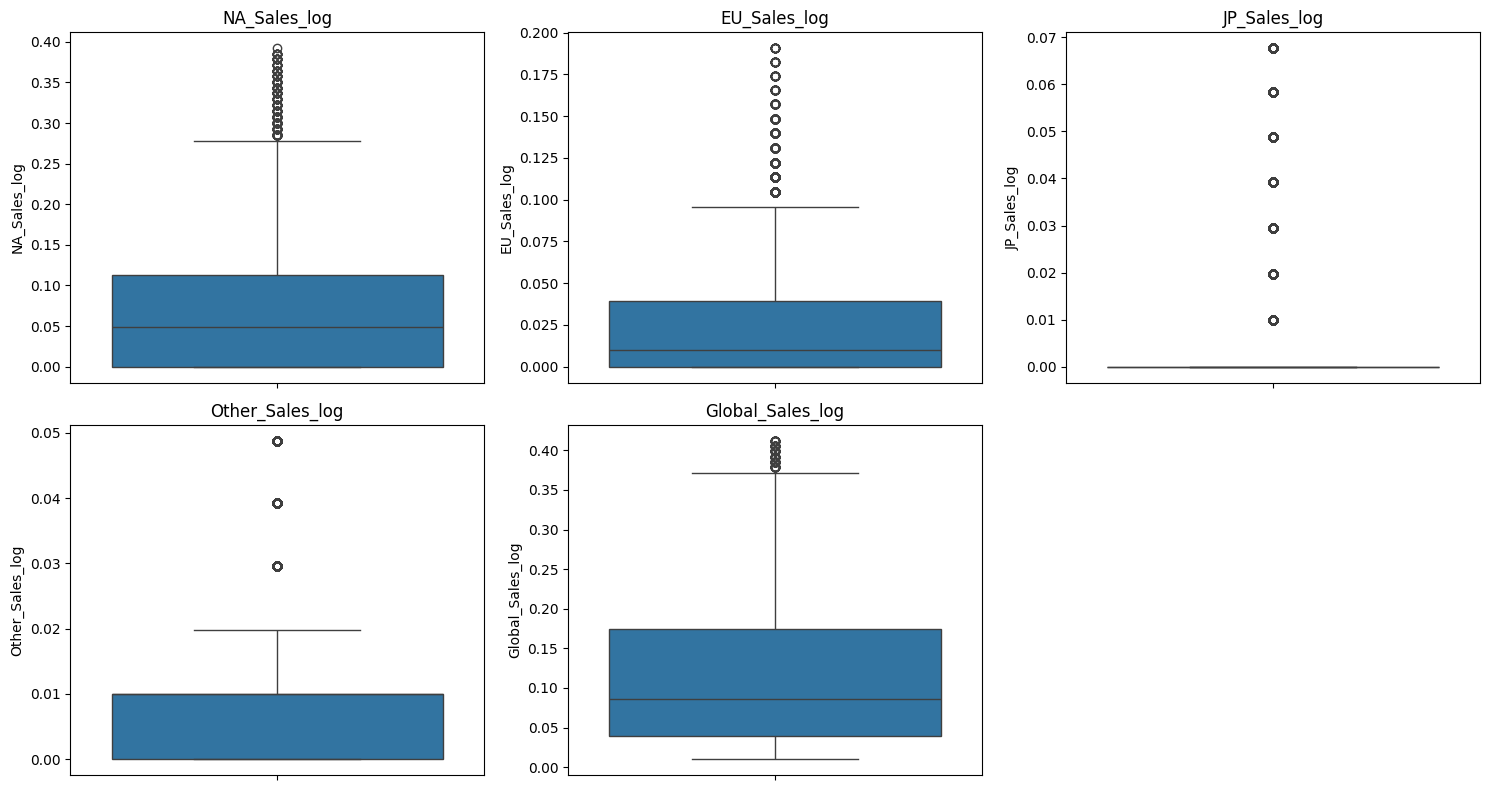

In [ ]:
plt.figure(figsize=(15, 8))

for i, col in enumerate(sales_log_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Ситуация с выбросами стала лучше.
Хотя точки выше новых "усов" все еще есть, их гораздо меньше чем было изначально.

**Вывод:** с помощью ящика с усами обнаружили выбросы в продажах, удалили их с помощью межквартильного размаха.

#### 5 Обработка неправильных типов данных

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Name              10671 non-null  object 
 1   Platform          10671 non-null  object 
 2   Year_of_Release   10671 non-null  float64
 3   Genre             10671 non-null  object 
 4   Publisher         10671 non-null  object 
 5   NA_Sales          10671 non-null  float64
 6   EU_Sales          10671 non-null  float64
 7   JP_Sales          10671 non-null  float64
 8   Other_Sales       10671 non-null  float64
 9   Global_Sales      10671 non-null  float64
 10  Critic_Score      10671 non-null  float64
 11  Critic_Count      10671 non-null  float64
 12  User_Score        10671 non-null  float64
 13  User_Count        10671 non-null  float64
 14  Developer         10671 non-null  object 
 15  Rating            10671 non-null  object 
 16  NA_Sales_log      10671 non-null  float64


In [ ]:
# object -> int (можно в datetime)
data['Year_of_Release'] = data['Year_of_Release'].astype(int)

In [ ]:
# float -> int (там только целые значения)
int_cols = ['Critic_Score', 'Critic_Count', 'User_Score', 'User_Count']

for col in int_cols:
    data[col] = data[col].astype(int)

In [ ]:
# object -> категориальные
cat_cols = [ 'Platform', 'Genre', 'Rating',  'Name', 'Publisher', 'Developer']

for col in cat_cols:
    data[col] = data[col].astype('category')

In [ ]:
print(data.info())

data.head(1)

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Name              10671 non-null  category
 1   Platform          10671 non-null  category
 2   Year_of_Release   10671 non-null  int64   
 3   Genre             10671 non-null  category
 4   Publisher         10671 non-null  category
 5   NA_Sales          10671 non-null  float64 
 6   EU_Sales          10671 non-null  float64 
 7   JP_Sales          10671 non-null  float64 
 8   Other_Sales       10671 non-null  float64 
 9   Global_Sales      10671 non-null  float64 
 10  Critic_Score      10671 non-null  int64   
 11  Critic_Count      10671 non-null  int64   
 12  User_Score        10671 non-null  int64   
 13  User_Count        10671 non-null  int64   
 14  Developer         10671 non-null  category
 15  Rating            10671 non-null  category
 16  NA_Sales_log      10671 

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,35,5,22,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211


**Вывод**: привели все признаки к корректным типам:

- Числовые признаки (`Year_of_Release`, `User_Score`, `Critic_Score`, `Critic_Count`, `User_Count`, `Sales`'ы) были приведены к `float` или `int`.

- Качественные признаки (`Platform`, `Genre`, `Publisher`, `Developer`, `Rating`, `Name`) были приведены к типу `category`.

После этой обработки все данные стали однородными, нет типа `object`.

#### 6 Преобразование качественных признаков

Этих категорий, которые представлены ниже, не так много, как в остальных качественнных признаках


In [ ]:
print(data.Platform.unique())
print(data.Genre.unique())
print(data.Rating.unique())

['X360', '2600', 'DS', 'GC', 'PS', ..., '3DO', 'GG', 'WS', 'PCFX', 'TG16']
Length: 31
Categories (31, object): ['2600', '3DO', '3DS', 'DC', ..., 'WiiU', 'X360', 'XB', 'XOne']
['Action', 'Sports', 'Role-Playing', 'Puzzle', 'Adventure', ..., 'Fighting', 'Shooter', 'Racing', 'Simulation', 'Strategy']
Length: 12
Categories (12, object): ['Action', 'Adventure', 'Fighting', 'Misc', ..., 'Shooter', 'Simulation',
                          'Sports', 'Strategy']
['E', 'Unknown', 'E10+', 'T', 'M', 'EC', 'RP', 'K-A']
Categories (8, object): ['E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', 'Unknown']


их можно закодировать.


Если спользовать `One Hot Encoding`, то это приведет к раздуванию датасета.

Используем `LabelEncoder`, в нем каждой категории присваивается число (напр `PS3 - 1, Wii - 2, PC - …`)

In [ ]:
le = LabelEncoder()
for col in ['Platform', 'Genre', 'Rating']:
    data[col + '_code'] = le.fit_transform(data[col])
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,Developer,Rating,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,Blitz Games Studios,E,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,Unknown,Unknown,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7


Однако качественные признаки `'Name'`, `'Publisher'`, `'Developer'` остались незакодированными.

(`Name` можно было бы и удалить вовсе, так как в моделях вероятнее всего этот признак не будем использовать, но пока пусть остается.)

Так как их уникальных значений очень много, можно закодировать их через `frequency encoder` (не значениями `0,...,k` а их частотой появления в дф, это дает меньше аффекта для линейных моделей, которые могуть считать новые признаки упорядоченными)



In [ ]:
for col in ['Publisher', 'Developer', 'Name']:
    freq = data[col].value_counts() / len(data)
    data[col + '_freq_code'] = data[col].map(freq)
data.head(2)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094


**Вывод**: закодировали качественные признаки методами `Label&Frequency Encoder`

### b) Доп предобработка для практической работы №3

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Name                 10671 non-null  category
 1   Platform             10671 non-null  category
 2   Year_of_Release      10671 non-null  int64   
 3   Genre                10671 non-null  category
 4   Publisher            10671 non-null  category
 5   NA_Sales             10671 non-null  float64 
 6   EU_Sales             10671 non-null  float64 
 7   JP_Sales             10671 non-null  float64 
 8   Other_Sales          10671 non-null  float64 
 9   Global_Sales         10671 non-null  float64 
 10  Critic_Score         10671 non-null  int64   
 11  Critic_Count         10671 non-null  int64   
 12  User_Score           10671 non-null  int64   
 13  User_Count           10671 non-null  int64   
 14  Developer            10671 non-null  category
 15  Rating               

In [ ]:
data.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,...,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code
3882,Epic Mickey 2: The Power of Two,X360,2012,Action,Disney Interactive Studios,0.32,0.15,0.0,0.04,0.51,...,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187
3883,Fishing Derby,2600,2007,Sports,Activision,0.48,0.03,0.0,0.01,0.51,...,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094
3885,Spectrobes: Beyond the Portals,DS,2008,Role-Playing,Disney Interactive Studios,0.36,0.11,0.0,0.04,0.51,...,0.104360,0.0,0.039221,0.41211,4,7,1,0.011714,0.000094,0.000094
3889,Madden NFL 2004,GC,2003,Sports,Electronic Arts,0.40,0.10,0.0,0.01,0.51,...,0.095310,0.0,0.009950,0.41211,7,10,0,0.062974,0.003655,0.000187
3893,Virtual Pool,PS,1997,Sports,Interplay,0.28,0.19,0.0,0.03,0.51,...,0.173953,0.0,0.029559,0.41211,15,10,7,0.002437,0.375129,0.000094


#### 📑корпус для pLSA

Изначально, я хотела использовать только лишь `Name` для тематического моделирования.

Однако, для тематического моделирования требуется довольно большой корпус текста для корректной его работы, "соберем" его из имеющихся в наших данных текстовых описаний таким образом: corpus=`Name`+`Platform`+`Genre`+`Publisher`.

In [ ]:
# Берем только категориальные столбцы
cat_cols = ["Name", "Platform", "Genre", "Publisher"]

# Создаем корпус (каждая строка = документ)
corpus = data[cat_cols].astype(str).agg(" ".join, axis=1)
corpus.head()

# Новый датафрейм только с текстовым корпусом
data_corpus = pd.DataFrame({
    "Document": corpus})

data_corpus.head()

,Document
3882,Epic Mickey 2: The Power of Two X360 Action Di...
3883,Fishing Derby 2600 Sports Activision
3885,Spectrobes: Beyond the Portals DS Role-Playing...
3889,Madden NFL 2004 GC Sports Electronic Arts
3893,Virtual Pool PS Sports Interplay


In [ ]:
data_corpus = data_corpus.reset_index(drop=True)
data_corpus

,Document
0,Epic Mickey 2: The Power of Two X360 Action Di...
1,Fishing Derby 2600 Sports Activision
2,Spectrobes: Beyond the Portals DS Role-Playing...
3,Madden NFL 2004 GC Sports Electronic Arts
4,Virtual Pool PS Sports Interplay
...,...
10666,Samurai Warriors: Sanada Maru PS3 Action Tecmo...
10667,LMA Manager 2007 X360 Sports Codemasters
10668,Haitaka no Psychedelica PSV Adventure Idea Fac...
10669,Spirits & Spells GBA Platform Wanadoo


Тем самым, создали новый датафрейм `data_corpus` с корпусом для тематического моделирования.

####❓Удалим старые признаки


Так как мы преобразовали исходные признаки (логарифмировали, закодировали категориальные), первоначальные признаки можно убрать из датасета, ибо они по сути дублируют информацию и все равно будут сильно коррелировать с новыми признаками. Однако потом их нельзя будет использовать для визуализации.

In [ ]:
data.drop(columns=['Name',
                   'Platform', 'Genre', 'Publisher','NA_Sales',
                   'EU_Sales','JP_Sales','Other_Sales','Global_Sales','Developer',
                   'Rating'], inplace=True)

#### таргет для LDA/QDA

зададим классы внутри Global_Sales_log наиболее простым способом.

In [ ]:
# Порог по медиане
threshold = data["Global_Sales_log"].median()

# Новый таргет для классификации
data["Sales_Class"] = (data["Global_Sales_log"] >= threshold).astype(int)
data["Sales_Class"].value_counts()

,count
Sales_Class,
1,5341
0,5330


**Проверка на дисбаланс классов**

In [ ]:
display(data['Sales_Class'].value_counts())
print(f'Число индивидов в малочисленном классе:', data['Sales_Class'].value_counts().min())
print(f'Число индивидов в многочисленном классе:', data['Sales_Class'].value_counts().max())

,count
Sales_Class,
1,5341
0,5330


Число индивидов в малочисленном классе: 5330
Число индивидов в многочисленном классе: 5341


<!-- Видим, что есть сильный дисбаланс классов.  -->
Видим, что классы сбалансированы.

**Проверка на корреляцию признаков**

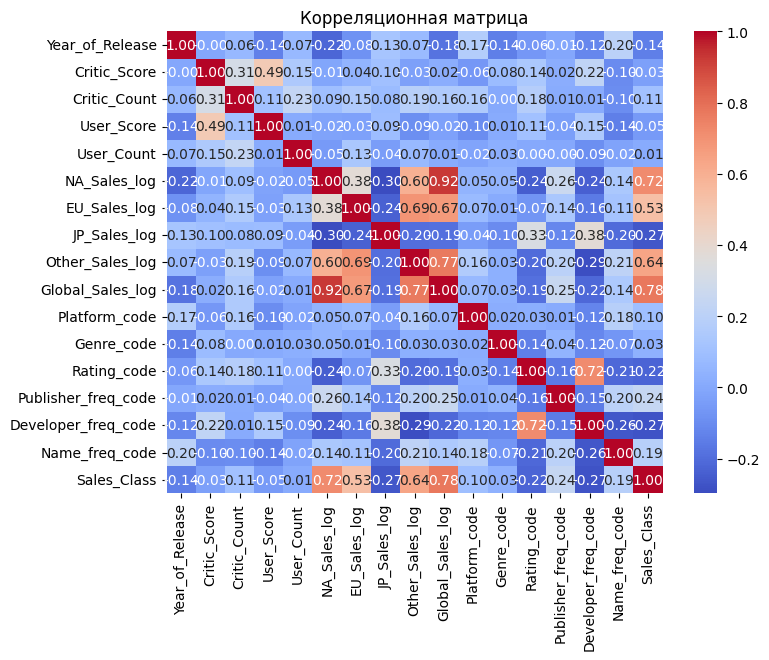

In [ ]:
# 1.Корреляционная матрица
external_corr = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(external_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Корреляционная матрица')
plt.show()

Видим, что есть:
- корреляция у продаж (`Global_Sales` с `NA_Sales` особенно сильная(0,92) и с продажами в остальных регионах)
- рейтинг и разработчик (0,72)
- оценки игроков и критиков (0,49)
- отрицательные корреляции отсутствуют

Корреляция с целевым признаком(`Sales_Class`):
- высокая положительная корреляция с продажами
- чуть менее сильная с продажами в Японии (возможно, из-за не такого сильного разброса значений внутри признака).

<!-- Корреляция с целевым признаком(`Genre_code`):
ни один из представленных признаков особо сильно не коррелирует, примерно везде значения колеблятся около 0.  -->


**Вывод:** классы сбалансированные, по таргету корреляция положительная, особенно высокая с признаками, связанными с продажами(оно и логично).

<!-- низкая.  -->

### c) Частичный повтор работы №1

#### 7 Разделение выборки (на тренировочную, тестовую, валидационную)

Разделим выборку в соотношении `60/20/20`




In [ ]:
# X — все признаки,
# y — целевая переменная #(например, Global_Sales_log)
# # При интерпертации результатов надо будет вернуться (y_pred_real = np.expm1(y_pred_log))
X = data.drop(columns=['Sales_Class'])
y = data['Sales_Class']

# сначала выделяем тренировочную 60% и временную 40% (для валидации и теста)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)

# затем делим оставшиеся 40% пополам: 20% валидация, 20% тест
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# проверим размеры выборок
print("Train:", X_train.shape, "Validation:", X_val.shape, "Test:", X_test.shape)

Train: (6402, 16) Validation: (2134, 16) Test: (2135, 16)


или в процентах:

In [ ]:
n_total = len(data)
print(f"Train: {X_train.shape[0]} ({X_train.shape[0]/n_total*100:.1f}%)")
print(f"Validation: {X_val.shape[0]} ({X_val.shape[0]/n_total*100:.1f}%)")
print(f"Test: {X_test.shape[0]} ({X_test.shape[0]/n_total*100:.1f}%)")

Train: 6402 (60.0%)
Validation: 2134 (20.0%)
Test: 2135 (20.0%)


как и ожидалось.

**Вывод**: При `random_state=42` разделили выборку на три части:

- Тренировочная выборка (`X_train, y_train`) — 60% данных (используется для обучения моделей)

- Валидационная выборка (`X_val, y_val`)— 20% данных (используется для подбора гиперпараметров и контроля переобучения)

- Тестовая выборка (`X_test, y_test`)— 20% данных (используется для финальной оценки качества модели)

#### 8 Стандартизация данных

Цель — преобразовать исходный набор в новый со средним значением равным 0 и стандартным отклонением равным 1.

Стандартизация нужна, чтобы все числовые признаки имели одинаковый масштаб. Это важно для некоторых чувствительных к нему моделей.

У нас, например, оценки критиков(0-100) и игроков(0-10) меняются в разных масштабах.

Стандартизуем числовые признаки.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10671 entries, 3882 to 16718
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_of_Release      10671 non-null  int64  
 1   Critic_Score         10671 non-null  int64  
 2   Critic_Count         10671 non-null  int64  
 3   User_Score           10671 non-null  int64  
 4   User_Count           10671 non-null  int64  
 5   NA_Sales_log         10671 non-null  float64
 6   EU_Sales_log         10671 non-null  float64
 7   JP_Sales_log         10671 non-null  float64
 8   Other_Sales_log      10671 non-null  float64
 9   Global_Sales_log     10671 non-null  float64
 10  Platform_code        10671 non-null  int64  
 11  Genre_code           10671 non-null  int64  
 12  Rating_code          10671 non-null  int64  
 13  Publisher_freq_code  10671 non-null  float64
 14  Developer_freq_code  10671 non-null  float64
 15  Name_freq_code       10671 non-null  f

In [ ]:
scaler = StandardScaler()

# выбираем признаки для стандартизации
num_features = [
    'Year_of_Release',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count',
    'NA_Sales_log',
    'EU_Sales_log',
    'Other_Sales_log'
]

# fit на train
scaler.fit(X_train[num_features])

# трансформируем train, test, val
X_train[num_features] = scaler.transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_val[num_features] = scaler.transform(X_val[num_features])

***Вывод***: стандартизировали числовые признаки (`'Year_of_Release','Critic_Score','Critic_Count',
'User_Score',
'User_Count',
'NA_Sales_log',
'EU_Sales_log',
'Other_Sales_log'`) с помощью `StandardScaler`

### **Вывод:**

предобработали данные для задач практической работы №3.
- сделали новый таргет для классификации с помощью Дискриминативного Анализа `Sales_Class`(класс 1\0-выше\ниже медианы)
- проверили на дисбаланс классов - данные сбалансированы
- проверили наличие корреляций меж признаков и признаков с таргетом (сильная корреляция с продажами в регионах)

- для тематического моделирования будем использовать corpus=`Name`+`Platform`+`Genre`+`Publisher`.

## 3 Использовать LDA/QDA

In [ ]:
data.head(2)

,Year_of_Release,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales_log,EU_Sales_log,JP_Sales_log,Other_Sales_log,Global_Sales_log,Platform_code,Genre_code,Rating_code,Publisher_freq_code,Developer_freq_code,Name_freq_code,Sales_Class
3882,2012,59,35,5,22,0.277632,0.139762,0.0,0.039221,0.41211,28,0,0,0.011714,0.000562,0.000187,1
3883,2007,71,21,7,24,0.392042,0.029559,0.0,0.009950,0.41211,0,10,7,0.059882,0.375129,0.000094,1


- Применим Линейный дискриминантный анализ:

In [ ]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

In [ ]:
acc_lda = accuracy_score(y_test, y_pred_lda)
print("Accuracy LDA:", acc_lda)
print(classification_report(y_test, y_pred_lda))

Accuracy LDA: 0.917096018735363
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1059
           1       1.00      0.84      0.91      1076

    accuracy                           0.92      2135
   macro avg       0.93      0.92      0.92      2135
weighted avg       0.93      0.92      0.92      2135



**Вывод:** Самая базовая модель классификации `LDA` отработала без ошибок и предупреждений, в общем то показывает довольно высокую `Accuracy=0,91`.

НО по `0` классу хуже `precision=0,86`, по `1` - `recall=0,84`.

- Применим Квадратичный дискриминантный анализ:

In [ ]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [ ]:
acc_qda = accuracy_score(y_test, y_pred_qda)
print("Accuracy QDA:", acc_qda)
print(classification_report(y_test, y_pred_qda))

Accuracy QDA: 0.9348946135831382
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1059
           1       0.91      0.97      0.94      1076

    accuracy                           0.93      2135
   macro avg       0.94      0.93      0.93      2135
weighted avg       0.94      0.93      0.93      2135



**Вывод:** Квадратичная модель уже отработала с предупреждением(кавариационные матрицы обоих классов не полного ранга, предлагают изменить параметр регуляризации).

НО `Accuracy` выше, чем у линейной модели на 2%, `precision` и `recall` уже не такие идеальные, но более сбалансированные по каждому из классов.

## 4 Использовать Probabilistic LSA

Напомню, корпус текста из изначального датасета с видеоиграми мы выделили в пункте *2.b).корпус для pLSA*.

Он имеет такую струтуру `corpus`=`Name`+`Platform`+`Genre`+`Publisher`

In [ ]:
data_corpus.head()

,Document
0,Epic Mickey 2: The Power of Two X360 Action Di...
1,Fishing Derby 2600 Sports Activision
2,Spectrobes: Beyond the Portals DS Role-Playing...
3,Madden NFL 2004 GC Sports Electronic Arts
4,Virtual Pool PS Sports Interplay


In [ ]:
data_corpus.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10671 entries, 0 to 10670
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Document  10671 non-null  object
dtypes: object(1)
memory usage: 83.5+ KB


### LSA

как было сказано в *лекции 4*: TruncaredSVD - реализация LSA в sklearn. Для того чтобы его применить, нам все еще необходимо немного предобработать данные, а именно:

- Преобразуем текст в мешок слов (Bag-of-Words)

In [ ]:
# создаем матрицу частот слов
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(data_corpus["Document"])

print("Размерность матрицы документов × термы:", X_counts.shape)

Размерность матрицы документов × термы: (10671, 7903)


In [ ]:
X_counts # разряженная матрица

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 75105 stored elements and shape (10671, 7903)>

Теперь, применим LSA (TruncatedSVD)

In [ ]:
# зададим количество тем (например,)
n_topics = 10
lsa = TruncatedSVD(n_components=n_topics, random_state=42)
X_topics = lsa.fit_transform(X_counts)

In [ ]:
X_topics

array([[ 0.84208235, -0.24387213,  0.85520883, ...,  0.05873116,
         0.78377337, -0.11939739],
       [ 0.33907232,  0.3974639 , -0.00828989, ...,  0.35148648,
         0.22978955, -0.22466789],
       [ 0.82845447, -0.39432599, -0.72123231, ..., -0.05608559,
         0.79245828, -0.34592803],
       ...,
       [ 0.21802841, -0.0622682 , -0.09774017, ...,  0.78560192,
        -0.39159932,  0.25920542],
       [ 0.13189815,  0.04259534,  0.01234052, ..., -0.10210171,
        -0.00613202,  0.04786754],
       [ 0.17940465, -0.03751154, -0.00923963, ...,  0.07168616,
        -0.1175107 ,  0.02860395]])

Просмотрим полученные темы (топ-слова)

In [ ]:
terms = vectorizer.get_feature_names_out()

def print_top_words(model, terms, n_top_words=5):
    for idx, comp in enumerate(model.components_):
        top_indices = comp.argsort()[::-1][:n_top_words]
        top_terms = [terms[i] for i in top_indices]
        print(f"Тема {idx+1}: {' | '.join(top_terms)}")

print_top_words(lsa, terms)

Тема 1: action | ds | entertainment | games | sports
Тема 2: entertainment | sports | digital | konami | ps2
Тема 3: action | x360 | activision | pc | ps3
Тема 4: games | sports | namco | bandai | arts
Тема 5: sports | electronic | arts | ds | action
Тема 6: playing | role | pc | interactive | psp
Тема 7: adventure | racing | interactive | ps2 | pc
Тема 8: adventure | sports | psp | ps2 | factory
Тема 9: interactive | misc | wii | sports | disney
Тема 10: misc | arts | electronic | wii | psp


Сконкатенируем датафреймы, чтобы увидеть нагляднее, к какой теме отнесли каждую запись, и что вообще мы получили за эти шаги.

In [ ]:
topic_df = pd.DataFrame(X_topics, columns=[f"Topic_{i+1}" for i in range(n_topics)])
result = pd.concat([data_corpus, topic_df], axis=1)
result.head(3)

,Document,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10
0,Epic Mickey 2: The Power of Two X360 Action Di...,0.842082,-0.243872,0.855209,-0.341631,0.384430,0.211682,0.398766,0.058731,0.783773,-0.119397
1,Fishing Derby 2600 Sports Activision,0.339072,0.397464,-0.008290,0.423498,0.467874,-0.060263,-0.234996,0.351486,0.229790,-0.224668
2,Spectrobes: Beyond the Portals DS Role-Playing...,0.828454,-0.394326,-0.721232,-0.351329,0.143743,1.339046,-0.010255,-0.056086,0.792458,-0.345928


Короче говоря, темы конечно как-то были определены, но не до конца ясно, как это интерпертировать. Конечно, данных очень мало для задачи тематического моделирования, и зачастую эти слова - названия компаний\игр, по которым качественно разделить на тематики не так просто

**Вывод:**
Можно сказать, что

- Тема 1 и Тема 5 включают слова action, sports, games, arts, что позволяет интерпретировать их как общий кластер экшен и спортивных игр, преимущественно разработанных крупными издателями, такими как Electronic Arts.

- Тема 2 и Тема 4 содержат слова entertainment, digital, konami, namco, bandai - это кластеры, связанные с японскими и азиатскими разработчиками, ориентированными на консольные платформы (PS2, PSP).

- Тема 3 объединяет action, x360, activision, pc, ps3 — что указывает на игры, выпускавшиеся для западных консолей и ПК, в основном от крупных издателей (Activision).

- Тема 6 (слова playing, role, pc, interactive, psp) отражает жанр ролевых игр (RPG), представленных на различных платформах.

- Тема 7 и Тема 8 объединяют adventure, racing, interactive, ps2, psp - это приключенческие и гоночные игры, преимущественно на консолях Sony.

- Тема 9 и Тема 10 содержат слова interactive, misc, wii, disney, что указывает на семейные игры, часто выпускаемые под брендом Disney Interactive Studios для платформ Nintendo.

но это далеко не самое точное и интуитивное деление.

### pLSA

Метод pLSA, напротив, не имеет реализации в sklearn.

Есть несколько путей решения этой невезухи:
- реализовать метод самостоятельно, опираясь на *лекцию 4*, как EM-метод
- использовать сторонние реализации
<!-- , например из библиотеки `genism` (`from gensim.models import LsiModel` - реализация pLSA на самом деле) -->

Пойдем первым, трудоемким путем.

In [ ]:
vectorizer = CountVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    stop_words='english'
)

X = vectorizer.fit_transform(data_corpus["Document"]).toarray()  # (D × V)
vocab = np.array(vectorizer.get_feature_names_out())

D, V = X.shape
print(f"Документов: {D}, слов в словаре: {V}")
print("Пример словаря:", vocab[:15])

ndw = X.astype(float)  # n_{d,w}

Документов: 10671, слов в словаре: 7938
Пример словаря: ['0' '00' '000' '007' '01' '02' '03' '04' '06' '07' '08' '09' '1' '10'
 '100']


In [ ]:
class PLSA:
    def __init__(self, n_topics=10, max_iter=25, eps=1e-12, random_state=42):
        self.K = n_topics
        self.max_iter = max_iter
        self.eps = eps
        self.rng = np.random.RandomState(random_state)
        self.phi = None      # p(word|topic)
        self.theta = None    # p(topic|document)

    def _initialize(self, V, D):
        self.phi = self.rng.rand(V, self.K)
        self.phi = self.phi / (self.phi.sum(axis=0, keepdims=True) + self.eps)

        self.theta = self.rng.rand(self.K, D)
        self.theta = self.theta / (self.theta.sum(axis=0, keepdims=True) + self.eps)

    def _e_step(self, ndw):
        D, V = ndw.shape
        p_t_given_dw = np.zeros((D, V, self.K))
        for d in range(D):
            unnorm = self.phi * self.theta[:, d]  # (V x K)
            denom = unnorm.sum(axis=1, keepdims=True) + self.eps
            p_t_given_dw[d] = unnorm / denom
        return p_t_given_dw

    def _m_step(self, ndw, p_t_given_dw):
        D, V = ndw.shape
        n_wt = np.zeros((V, self.K))
        n_td = np.zeros((self.K, D))

        for d in range(D):
            ndw_d = ndw[d, :, None]  # (V, 1)
            n_wt += ndw_d * p_t_given_dw[d]
            n_td[:, d] = (ndw_d * p_t_given_dw[d]).sum(axis=0)

        nt = n_wt.sum(axis=0)
        nd = n_td.sum(axis=0)

        self.phi = n_wt / (nt[None, :] + self.eps)
        self.theta = n_td / (nd[None, :] + self.eps)

    def fit(self, ndw, vocab=None, verbose=True):
        """
        ndw: матрица (D x V) с частотами слов в документах
        vocab: массив слов (для интерпретации топ-слов)
        """
        D, V = ndw.shape
        self._initialize(V, D)
        prev_ll = None

        for it in range(1, self.max_iter + 1):
            # E-step
            p_t_given_dw = self._e_step(ndw)

            # M-step
            self._m_step(ndw, p_t_given_dw)

            # Лог-вероятность и перплексия
            ll = self.compute_log_likelihood(ndw)
            perp = self.compute_perplexity(ndw)

            if verbose:
                print(f"Итерация {it:2d}: log-likelihood = {ll:.4f}, perplexity = {perp:.4f}")

            if prev_ll is not None and abs(ll - prev_ll) < 1e-6:
                if verbose:
                    print(f"Сошлось на итерации {it}")
                break
            prev_ll = ll

        return self

    def compute_log_likelihood(self, ndw):
        ll = 0.0
        D, V = ndw.shape
        for d in range(D):
            p_dw = (self.phi * self.theta[:, d]).sum(axis=1) + self.eps
            ll += (ndw[d] * np.log(p_dw)).sum()
        return ll

    def compute_perplexity(self, ndw):
        N = ndw.sum()
        ll = self.compute_log_likelihood(ndw)
        return np.exp(-ll / N)

    def get_theta_df(self, data_corpus):
        """Возвращает таблицу распределений p(topic|document)"""
        theta_df = pd.DataFrame(self.theta.T, columns=[f"Topic_{i+1}" for i in range(self.K)])
        theta_df["Document"] = data_corpus["Document"]
        return theta_df

    def get_top_words(self, vocab, top_n=7):
        """Возвращает топ-слова для каждой темы"""
        topics = []
        for t in range(self.K):
            top_idx = np.argsort(-self.phi[:, t])[:top_n]
            topics.append(vocab[top_idx].tolist())
        return topics


In [ ]:
# Создаем и обучаем модель
plsa_model = PLSA(n_topics=10, max_iter=25)
plsa_model.fit(ndw)

Итерация  1: log-likelihood = -524805.9674, perplexity = 791.2464
Итерация  2: log-likelihood = -519490.6720, perplexity = 739.5325
Итерация  3: log-likelihood = -511769.6263, perplexity = 670.3734
Итерация  4: log-likelihood = -501724.2714, perplexity = 589.9836
Итерация  5: log-likelihood = -491157.9706, perplexity = 515.8057
Итерация  6: log-likelihood = -482007.3708, perplexity = 459.1459
Итерация  7: log-likelihood = -474952.7945, perplexity = 419.7501
Итерация  8: log-likelihood = -469688.9953, perplexity = 392.5733
Итерация  9: log-likelihood = -465697.7663, perplexity = 373.1459
Итерация 10: log-likelihood = -462566.3944, perplexity = 358.5794
Итерация 11: log-likelihood = -460042.0316, perplexity = 347.2515
Итерация 12: log-likelihood = -458002.0918, perplexity = 338.3595
Итерация 13: log-likelihood = -456339.6695, perplexity = 331.2816
Итерация 14: log-likelihood = -454962.7852, perplexity = 325.5317
Итерация 15: log-likelihood = -453810.2692, perplexity = 320.7956
Итерация 1

(выполняла с "Серверный ускоритель Python 3 на базе Google Compute Engine ((TPU)).", т. к. моментами занимает более 12.7 ОЗУ, отрубая среду в коллабе. 1 итерация занимала ~ 20 сек)

In [ ]:
# Таблица распределений p(topic|document)
theta_df = plsa_model.get_theta_df(data_corpus)
theta_df.head(3)

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,Topic_10,Document
0,1.227673e-18,0.120207,7.600138e-19,2.625235e-01,2.348432e-18,2.753230e-01,1.586438e-08,8.826750e-17,3.419447e-01,1.653115e-06,Epic Mickey 2: The Power of Two X360 Action Di...
1,4.069538e-09,0.228181,3.912031e-03,3.464770e-04,1.612842e-24,1.108558e-10,1.997070e-01,1.232999e-18,8.192367e-08,5.678538e-01,Fishing Derby 2600 Sports Activision
2,5.402896e-05,0.498321,2.481548e-27,3.042234e-20,2.400175e-01,2.614445e-01,1.624911e-04,1.732403e-13,6.452980e-13,9.941419e-24,Spectrobes: Beyond the Portals DS Role-Playing...


In [ ]:
# Итоговая перплексия
final_perplexity = plsa_model.compute_perplexity(ndw)
print(f"\nИтоговая perplexity модели: {final_perplexity:.4f}")


Итоговая perplexity модели: 297.1443


In [ ]:
# Топ-слова
top_n = 7
topics = plsa_model.get_top_words(vocab, top_n=top_n)
print("\nТоп-слова для каждой темы:")
for i, words in enumerate(topics):
    print(f"Тема {i+1}: {', '.join(words)}")


Топ-слова для каждой темы:
Тема 1: ds, ubisoft, simulation, adventure, shooter, star, s
Тема 2: entertainment, digital, konami, misc, adventure, ds, disney
Тема 3: sports, arts, electronic, misc, entertainment, wii, ps2
Тема 4: action, gba, fighting, thq, xb, capcom, wii
Тема 5: games, role, playing, namco, bandai, strategy, ps
Тема 6: interactive, ps3, studios, game, pc, x360, adventure
Тема 7: racing, interactive, ps, games, xb, world, psp
Тема 8: shooter, games, puzzle, ds, electronic, arts, pc
Тема 9: action, entertainment, platform, activision, x360, sony, computer
Тема 10: ps2, sports, sega, action, s, misc, gba


Темы такие же не особо интуитивные, к тому же видно, что возможно не хватило итераций для полноценного отбора их из корпуса (напр., есть тема `s`- безумно информативная...)

## 5 Основные метрики

### **Accuracy** для LDA/QDA

In [ ]:
# Дублирую для удобства
print("Accuracy LDA:", acc_lda)
print(classification_report(y_test, y_pred_lda))
print("-"*50)
print("Accuracy QDA:", acc_qda)
print(classification_report(y_test, y_pred_qda))

Accuracy LDA: 0.917096018735363
              precision    recall  f1-score   support

           0       0.86      1.00      0.92      1059
           1       1.00      0.84      0.91      1076

    accuracy                           0.92      2135
   macro avg       0.93      0.92      0.92      2135
weighted avg       0.93      0.92      0.92      2135

--------------------------------------------------
Accuracy QDA: 0.9348946135831382
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1059
           1       0.91      0.97      0.94      1076

    accuracy                           0.93      2135
   macro avg       0.94      0.93      0.93      2135
weighted avg       0.94      0.93      0.93      2135



### (**Perplexity**) **Доля объяснённой дисперсии** для LSA


**Perplexity* — это метрика, применяемая в вероятностных моделях тем, таких как pLSA, мера того, насколько хорошо распределение вероятностей предсказывает выборку...

Вообще говоря, `lsa` (TruncatedSVD из sklearn) не является вероятностной моделью в строгом смысле — она не оценивает вероятности слов и документов, а выполняет линейное разложение матрицы частот.

Поэтому perplexity в явном виде для TruncatedSVD посчитать нельзя, потому что модель не вычисляет логарифмы вероятностей, на основе которых определяется perplexity. Для нее можно посчитать долю обьясненной дисперсии:

**Доля объяснённой дисперсии* — это мера, которая показывает, какая часть общей изменчивости данных объясняется моделью.

In [ ]:
explained_variance = lsa.explained_variance_ratio_
total_variance = explained_variance.sum()

print("Доля объяснённой дисперсии по темам:", explained_variance)
print("Суммарная доля объяснённой дисперсии:", total_variance)

Доля объяснённой дисперсии по темам: [0.01033356 0.02982085 0.02791556 0.02478218 0.02338024 0.02038836
 0.01774402 0.01759359 0.0167887  0.01617386]
Суммарная доля объяснённой дисперсии: 0.20492090949844793


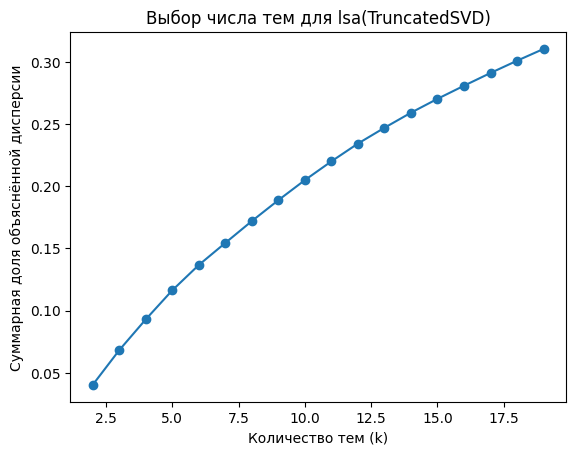

In [ ]:
components = range(2, 20)
variance = []

for k in components:
    lsa_model = TruncatedSVD(n_components=k, random_state=42)
    lsa_model.fit(X_counts)
    variance.append(lsa_model.explained_variance_ratio_.sum())

plt.plot(components, variance, marker='o')
plt.xlabel('Количество тем (k)')
plt.ylabel('Суммарная доля объяснённой дисперсии')
plt.title('Выбор числа тем для lsa(TruncatedSVD)')
plt.show()

Если кратко - то с задачей справилось плохо, обьясняется при 20 тематиках обьясяняется всего около 30% дисперсии. Это мало. Рост этой зависимости тоже медленный. (это связанно с неподходящими данными, в первую очередь)

### **Perplexity** для pLSA


А вот для pLSA, можно и нужно посчитать перплексию:

In [ ]:
final_perplexity = plsa_model.compute_perplexity(ndw)
print(f"\nИтоговая perplexity модели: {final_perplexity:.4f}")


Итоговая perplexity модели: 297.1443


Ооочень далека от идеала.. но заметим, что от начальной перплексии удалось уменьшить показатель на 500 единиц за всего 25 итераций!

## 6 Вывод. Алгоритмы.






**Вывод:**
LDA/QDA:

- Самая базовая модель классификации `LDA` отработала без ошибок и предупреждений, в общем то показывает довольно высокую `Accuracy=0,91`.

НО по `0` классу хуже `precision=0,86`, по `1` - `recall=0,84`.

- Квадратичная модель `QDA` отработала с предупреждением(кавариационные матрицы обоих классов не полного ранга, предлагают изменить параметр регуляризации).

НО `Accuracy` выше, чем у линейной модели на 2%, `precision` и `recall` уже не такие идеальные, но более сбалансированные по каждому из классов.

⇒ При Дискриминантном анализе было бы предпочтительнее использовать LDA на моих данных, так как это банально приносит меньше ошибок.

**Вывод:** LSA/pLSA:

- `LSA` отработал быстро, без ошибок, радует, что у этого метода уже есть готовая реализация. Разделил на 10 тематик, но это далеко не самое точное и интуитивное деление, что подтверждает низкая доля (=30%) обьясненной дисперсии.

- `pLSA` а именно его собственная реализация не может похвастаться скоростью, и итоговой `perplexity=297` при том же не шибко интуитивном делении на 10 тематик.

⇒ При тематическом моделировании, несмотря на странную постановку задачи на моих данных, бало бы предпочтительнее использовать LSA, а не его вероятностную модификацию, хотя бы потому, что это занимает гораздо меньше вычислительных ресурсов, и выдает все тот же,плохо интерпретируемый результат.


(Основная проблема на мой взгляд для задачи тематического моделирования - неподходящие исходные данные. Уверена, на приемлимых данных удалось бы получить приемлимый результат).

## 7 Вывод. Что более уместно?



**Вывод:**

Естественно, изначальный датасет `Video_Games.csv` подходил для задачи *регрессии* продаж наиболее уместно.

Однако, затем, искусственно разделив их на классы по этим же самым продажам мы смогли привести их к виду, в котором можно решать задачу *классификации*.  

Выделив текстовые компоненты из датасета, мы сделали что-то похожее на корпус, подходящий для задачи *тематического моделирования*.

Я клоню к тому, что применение LDA/QDA в этой работе более уместно, чем pLSA. Но в целом, подогнать данные к этой задаче все еще возможно, он не неприменим вообще, хотя и не совем подходит, как например статьи, отзывы или документация, с гораздо более общирным корпусом текста и понятными тематиками.



---



P.S. возможно, не надо было упираться на своем датасете, и выбрать подходящие данные для задачи тематического моделирования...

Проверим это предположение в главе ниже :)

# +⚠️📑 Тематическое моделирование на более подходящем корпусе

Данные взяла [отсюда](https://www.kaggle.com/datasets/therohk/million-headlines) (https://www.kaggle.com/datasets/therohk/million-headlines)

**О наборе данных**

- Достаточно классический датасет.

- Содержит данные о заголовках новостей, опубликованных за девятнадцать лет.

- Источник: авторитетный австралийский новостной ресурс ABC (Australian Broadcasting Corporation). Сайт агентства: (http://www.abc.net.au)

**Признаки:**

| Название колонки | Описание |
|------------------|----------|
| publish_date    | Дата публикации статьи в формате ггггММдд|
| headline_text   | Текст заголовка в кодировке ASCII, английский, строчными буквами |


- Дата начала сбора заголовков: 19.02.2003; Дата окончания: 31.12.2021
- Всего 1 244 184 записи


> От автора: Углубившись в ключевые слова, можно увидеть все важные события, определившие последнее десятилетие, и как они развивались с течением времени. Например: война в Афганистане, финансовый кризис, многочисленные выборы, экологические катастрофы, терроризм, известные люди, преступная деятельность и так далее.


Считаем данные:

In [ ]:
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
news_corpus = pd.read_csv('/content/drive/MyDrive/ML-SPbU-HW/HW_3/abcnews-date-text.csv')

Mounted at /content/drive/


In [ ]:
news_corpus.head()

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


In [ ]:
news_corpus.drop(columns=['publish_date'], inplace=True)
news_corpus.head(3)

,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit


In [ ]:
news_corpus

,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers
...,...
1244179,two aged care residents die as state records 2...
1244180,victoria records 5;919 new cases and seven deaths
1244181,wa delays adopting new close contact definition
1244182,western ringtail possums found badly dehydrate...


## LSA

- Повторим применение метода LSA для более подходящих данных:

Преобразуем текст в мешок слов (Bag-of-Words)

In [ ]:
# создаем матрицу частот слов
vectorizer = CountVectorizer(stop_words='english')
X_counts = vectorizer.fit_transform(news_corpus["headline_text"])

print("Размерность матрицы документов × термы:", X_counts.shape)

Размерность матрицы документов × термы: (1244184, 105674)


Теперь, применим LSA (TruncatedSVD)

In [ ]:
# зададим количество тем (например, 10)
n_topics = 10
lsa = TruncatedSVD(n_components=n_topics, random_state=42)
X_topics = lsa.fit_transform(X_counts)

In [ ]:
X_topics

array([[ 8.42239364e-03,  9.10242095e-03,  1.06027194e-03, ...,
         8.87923872e-03,  3.49196182e-03,  1.13551161e-03],
       [ 2.26132311e-02,  1.21677577e-02, -3.40660558e-03, ...,
        -1.22188162e-02, -1.13951098e-02,  7.28364225e-04],
       [ 1.70387985e-02,  1.93266491e-02, -2.87266949e-04, ...,
         6.97773012e-03,  4.89835992e-03, -4.03659422e-03],
       ...,
       [ 1.95753236e-01,  9.89885349e-01, -4.07092415e-02, ...,
        -5.56250845e-02, -1.10083279e-01, -6.34915536e-02],
       [ 4.93362350e-03,  5.53506458e-03,  2.71098161e-03, ...,
        -8.25600747e-03,  1.54906533e-02,  3.13080975e-03],
       [ 1.75003901e-01,  9.92608557e-01, -3.82422394e-02, ...,
        -2.99797173e-02,  1.30675909e-02, -2.25713350e-03]])

Просмотрим полученные темы (топ-слова)

In [ ]:
terms = vectorizer.get_feature_names_out()

def print_top_words(model, terms, n_top_words=5):
    for idx, comp in enumerate(model.components_):
        top_indices = comp.argsort()[::-1][:n_top_words]
        top_terms = [terms[i] for i in top_indices]
        print(f"Тема {idx+1}: {' | '.join(top_terms)}")

print_top_words(lsa, terms)

Тема 1: police | man | new | court | charged
Тема 2: new | says | australia | council | zealand
Тема 3: man | court | charged | murder | accused
Тема 4: says | govt | council | australia | nsw
Тема 5: govt | nsw | court | council | australia
Тема 6: court | accused | face | says | told
Тема 7: australia | day | south | world | cup
Тема 8: council | plan | water | australian | health
Тема 9: nsw | council | sydney | coast | rural
Тема 10: interview | sydney | extended | health | coast


**Вывод:**

Уже видно, что тематики довольно логично и интуитивно понятнее выбираются(особенно, если сравнивать с видеоиграми). Например :
- Тема 1 явно связана с судами и полицией
- Тема 7 связана с кубком мира
- Тема 8 - о каком то плане, связанной с водой и здоровьем австралийцев

в целом, довольно легко представить, что новости с такими темами действительно бывали за этот промежуток времени. (Соотносится с описанием к данным.)

### **Доля объяснённой дисперсии** для LSA


**Perplexity* — это метрика, применяемая в вероятностных моделях тем, таких как pLSA, мера того, насколько хорошо распределение вероятностей предсказывает выборку...

Вообще говоря, `lsa` (TruncatedSVD из sklearn) не является вероятностной моделью в строгом смысле — она не оценивает вероятности слов и документов, а выполняет линейное разложение матрицы частот.

Поэтому perplexity в явном виде для TruncatedSVD посчитать нельзя, потому что модель не вычисляет логарифмы вероятностей, на основе которых определяется perplexity. Для нее можно посчитать долю обьясненной дисперсии:

**Доля объяснённой дисперсии* — это мера, которая показывает, какая часть общей изменчивости данных объясняется моделью.

In [ ]:
explained_variance = lsa.explained_variance_ratio_
total_variance = explained_variance.sum()

print("Доля объяснённой дисперсии по темам:", explained_variance)
print("Суммарная доля объяснённой дисперсии:", total_variance)

Доля объяснённой дисперсии по темам: [0.00592649 0.0051158  0.00493731 0.0034827  0.00268814 0.00287773
 0.0028254  0.00264934 0.0025265  0.00238202]
Суммарная доля объяснённой дисперсии: 0.03541144099017317


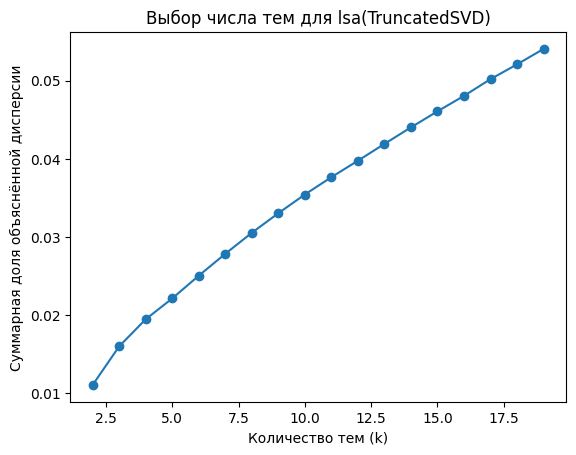

In [ ]:
components = range(2, 20)
variance = []

for k in components:
    lsa_model = TruncatedSVD(n_components=k, random_state=42)
    lsa_model.fit(X_counts)
    variance.append(lsa_model.explained_variance_ratio_.sum())

plt.plot(components, variance, marker='o')
plt.xlabel('Количество тем (k)')
plt.ylabel('Суммарная доля объяснённой дисперсии')
plt.title('Выбор числа тем для lsa(TruncatedSVD)')
plt.show()

Несмотря на более подходящие данные, на них, при 20 тематиках обьясяняется всего около 5% дисперсии. Это мало, даже меньше чем на текстовых описаниях в исходном датасете с играми. Рост этой зависимости такой же медленный.

## pLSA

- P.S. Использование самописного pLSA занимает значительно больше ресурсов,чем в прошлый раз и его применение на новых данных опускается...

<!-- А вот из сторонней библиотеки - почему бы и нет? -->

